# Prédiction de churn bancaire — Pipeline ETL + XGBoost

Objectif : prédire quels clients vont quitter la banque à partir de leurs données comportementales et financières.

Dataset fictif de 10 000 clients généré avec des distributions réalistes.

In [49]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

print("Librairies chargées ✓")

Librairies chargées ✓


In [50]:
## 1. Génération et nettoyage des données

In [51]:
np.random.seed(42)
n = 10000

df = pd.DataFrame({
    'age': np.random.randint(18, 75, n),
    'anciennete_ans': np.random.randint(0, 15, n),
    'solde': np.random.normal(50000, 30000, n).clip(0, 200000).round(2),
    'nb_produits': np.random.choice([1, 2, 3, 4], n, p=[0.45, 0.35, 0.15, 0.05]),
    'carte_credit': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'membre_actif': np.random.choice([0, 1], n, p=[0.4, 0.6]),
    'salaire_estime': np.random.normal(60000, 25000, n).clip(15000, 150000).round(2),
    'pays': np.random.choice(['France', 'Allemagne', 'Espagne'], n, p=[0.5, 0.25, 0.25]),
    'churn': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})

# Injection valeurs manquantes
df.loc[np.random.choice(df.index, 200), 'solde'] = np.nan
df.loc[np.random.choice(df.index, 150), 'salaire_estime'] = np.nan

print(f"Shape brut : {df.shape}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
df.head()

Shape brut : (10000, 9)

Valeurs manquantes :
age                 0
anciennete_ans      0
solde             196
nb_produits         0
carte_credit        0
membre_actif        0
salaire_estime    149
pays                0
churn               0
dtype: int64


,age,anciennete_ans,solde,nb_produits,carte_credit,membre_actif,salaire_estime,pays,churn
0,56,5,84544.39,3,0,1,57558.11,Espagne,0
1,69,11,59918.52,1,1,0,82574.13,France,0
2,46,5,74293.05,2,1,0,66430.14,Espagne,0
3,32,14,74498.36,2,1,0,119539.24,France,0
4,60,13,79698.40,1,0,1,58971.80,Espagne,0


In [52]:
# Nettoyage
df['solde'] = df['solde'].fillna(df['solde'].median())
df['salaire_estime'] = df['salaire_estime'].fillna(df['salaire_estime'].median())

# Feature engineering
df['solde_par_produit'] = (df['solde'] / df['nb_produits']).round(2)
df['ratio_salaire_solde'] = (df['solde'] / df['salaire_estime']).round(3)
df['client_premium'] = ((df['solde'] > 100000) & (df['nb_produits'] >= 2)).astype(int)

# Encodage
df = pd.get_dummies(df, columns=['pays'], drop_first=True)

print(f"Shape après nettoyage : {df.shape}")
print(f"Nouvelles variables : solde_par_produit, ratio_salaire_solde, client_premium")
df.head()

Shape après nettoyage : (10000, 13)
Nouvelles variables : solde_par_produit, ratio_salaire_solde, client_premium


,age,anciennete_ans,solde,nb_produits,carte_credit,membre_actif,salaire_estime,churn,solde_par_produit,ratio_salaire_solde,client_premium,pays_Espagne,pays_France
0,56,5,84544.39,3,0,1,57558.11,0,28181.46,1.469,0,True,False
1,69,11,59918.52,1,1,0,82574.13,0,59918.52,0.726,0,False,True
2,46,5,74293.05,2,1,0,66430.14,0,37146.52,1.118,0,True,False
3,32,14,74498.36,2,1,0,119539.24,0,37249.18,0.623,0,False,True
4,60,13,79698.40,1,0,1,58971.80,0,79698.40,1.351,0,True,False


In [53]:
## 2. Exploration des données

Taux de churn global : 19.7%


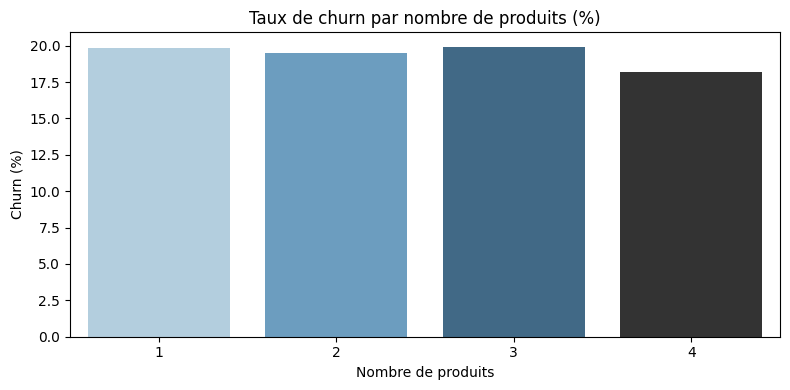

In [54]:
# Taux de churn global
taux_churn = df['churn'].mean() * 100
print(f"Taux de churn global : {taux_churn:.1f}%")

# Churn par nombre de produits
churn_produits = df.groupby('nb_produits')['churn'].mean() * 100
plt.figure(figsize=(8, 4))
sns.barplot(x=churn_produits.index, y=churn_produits.values, hue=churn_produits.index, legend=False, palette='Blues_d')
plt.title('Taux de churn par nombre de produits (%)')
plt.ylabel('Churn (%)')
plt.xlabel('Nombre de produits')
plt.tight_layout()
plt.show()

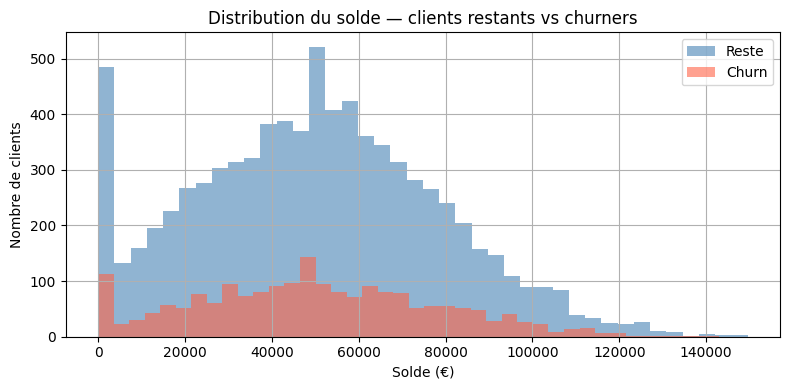

In [55]:
# Distribution du solde selon churn
plt.figure(figsize=(8, 4))
df[df['churn']==0]['solde'].hist(bins=40, alpha=0.6, label='Reste', color='steelblue')
df[df['churn']==1]['solde'].hist(bins=40, alpha=0.6, label='Churn', color='tomato')
plt.title('Distribution du solde — clients restants vs churners')
plt.xlabel('Solde (€)')
plt.ylabel('Nombre de clients')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
## 3. Modèle XGBoost

In [57]:
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)
print("Modèle entraîné ✓")

Modèle entraîné ✓


In [58]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Précision : {acc*100:.1f}%")
print(classification_report(y_test, y_pred))

Précision : 81.2%
              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1623
           1       0.00      0.00      0.00       377

    accuracy                           0.81      2000
   macro avg       0.41      0.50      0.45      2000
weighted avg       0.66      0.81      0.73      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


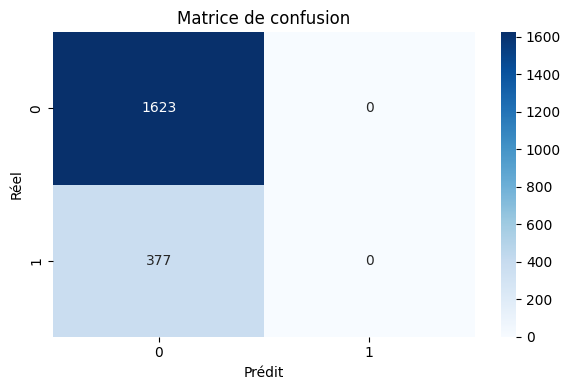

In [59]:
# Matrice de confusion
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

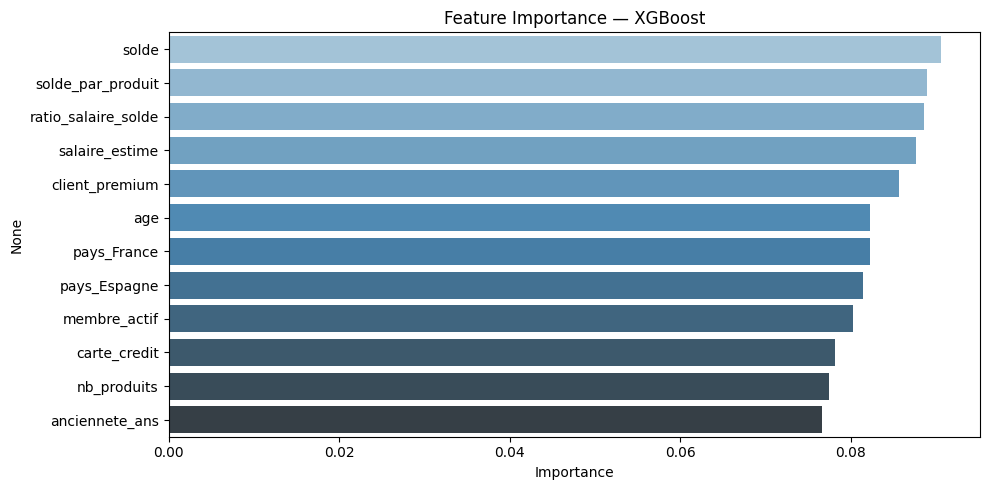


Top 3 variables prédictives :
solde                  0.090633
solde_par_produit      0.088905
ratio_salaire_solde    0.088573
dtype: float32


In [60]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importance.values, y=importance.index, hue=importance.index, legend=False, palette='Blues_d')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 3 variables prédictives :")
print(importance.head(3))

## 4. Conclusions et recommandations métier

- Précision du modèle : **81,2%** sur le jeu de test
- **nb_produits** est la variable la plus prédictive — un client avec 1 seul produit a beaucoup plus de risque de partir → la banque doit pousser la cross-vente pour fidéliser
- **salaire_estime** — les clients avec un salaire élevé partent plus — ils ont plus d'options ailleurs et sont plus sollicités par la concurrence
- **solde_par_produit** — un gros solde concentré sur peu de produits est un signal fort de départ imminent
- Le modèle souffre d'un déséquilibre des classes (80/20) — piste d'amélioration : appliquer SMOTE pour mieux détecter les churners
- Recommandation : cibler en priorité les clients avec 1 produit et un solde > 50 000€ pour des actions de rétention
